## 1. Purpose, scope and experimental contract

This file rebuilds the intended **KL-regularized G-learning, short-to-long curriculum, adaptive learning, and hierarchical strategy selection** experiment. It first diagnoses concrete failures in the original notebook, then evaluates controlled alternatives. Improvements mean correctness and measured evidence, not profitable trading.

Same STOCKS_GOOGL observations, actual dates, calibration on the first 252 rows, training through 60% of rows, validation from 60–80%, and final historical test from 80–100%. 

The final segment is held out from these training/selection computations, **not genuinely unseen research data**.

In [1]:
import json, sys, hashlib, inspect, time, platform
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from IPython.display import display, Markdown
import importlib.metadata as metadata
from gym_anytrading.datasets import STOCKS_GOOGL
from gym_anytrading.envs import StocksEnv, TradingEnv
OUT=Path('experiment_outputs'); OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize':(12,5),'figure.dpi':110,'axes.grid':True,'grid.alpha':.2})
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda z:f'{z:,.5f}')
def explain(s): display(Markdown('**Interpretation:** '+s))
def show(): plt.tight_layout(); plt.show(); plt.close('all')
SEEDS=[7,19,43]; BUDGET=24_000; GAMMA=.99; FEE=.001
versions={p:metadata.version(p) for p in ['numpy','pandas','scipy','matplotlib','gym-anytrading']}
display(pd.Series(versions,name='version').to_frame())

,version
numpy,2.4.6
pandas,3.0.5
scipy,1.17.1
matplotlib,3.11.1
gym-anytrading,2.0.0


## 2. Verify the exact dataset and preserve its dates

In [2]:
df=STOCKS_GOOGL.copy().sort_index()
assert isinstance(df.index,pd.DatetimeIndex) and df.index.is_unique
assert len(df)==2335 and np.isclose(df.Close.iloc[0],196.946945,atol=1e-5)
assert df.index.is_monotonic_increasing and np.isfinite(df.to_numpy()).all()
assert (df[['Open','High','Low','Close','Adj Close']]>0).all().all()
assert np.allclose(df.Close,df['Adj Close'])
DATA_HASH=hashlib.sha256(df.to_csv().encode()).hexdigest()
N=len(df); CAL=252; TRAIN_END=int(.6*N); VAL_END=int(.8*N)
SPLITS={'train':(CAL,TRAIN_END),'validation':(TRAIN_END,VAL_END),'test':(VAL_END,N)}
display(df.head()); display(pd.DataFrame([{'split':k,'first_open':df.index[a],'last_open':df.index[b-1],'transitions':b-a-1} for k,(a,b) in SPLITS.items()]))
print('SHA256:',DATA_HASH)
explain(f'Confirmed {N:,} source observations, {df.index[0].date()}–{df.index[-1].date()}. The original generated dates beginning 2010-01-01 are not used. Calibration rows are excluded from training episodes; their purpose is to define fixed feature bins.')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-05-22,198.52853,199.52452,196.19620,196.94694,196.94694,3433700
2009-05-26,196.17117,202.70270,195.19519,202.38238,202.38238,6202700
2009-05-27,203.02303,206.13614,202.60761,202.98299,202.98299,6062500
2009-05-28,204.54454,206.01602,202.50751,205.40541,205.40541,5332200
2009-05-29,206.26126,208.82382,205.55556,208.82382,208.82382,5291100


,split,first_open,last_open,transitions
0,train,2010-05-24,2014-12-12,1148
1,validation,2014-12-15,2016-10-20,466
2,test,2016-10-21,2018-08-29,466


SHA256: 050162e746a59f0c6e0a144978afb4adddb65d8b72dd331c774210cbdec38a5b


**Interpretation:** Confirmed 2,335 source observations, 2009-05-22–2018-08-29. The original generated dates beginning 2010-01-01 are not used. Calibration rows are excluded from training episodes; their purpose is to define fixed feature bins.

## 3. Source-code audit: why the original training can fail

The table shows errors to the original notebook’s zero-based cells.

In [3]:
audit=pd.DataFrame([
 ('6','Synthetic dates','pd.bdate_range replaces the source index','Preserve original dates.'),
 ('25,27','Reward/cost sign conflict','exp(-G/tau) favors lower values, but G is updated with positive rewards','Use cost=-reward consistently and a soft minimum backup.'),
 ('27,60','Sparse credit assignment','Only the final state/action receives the episode reward','Update every primitive transition or every completed option.'),
 ('23,60','Missing portfolio state','pos is sign of a price change, not current holding','Include actual cash/long position in the state.'),
 ('27,60','Repeated initial window','reset starts at the same tick every episode','Sample starts across training history.'),
 ('27,44,60','Unreliable risk denominator','std(diff(realized profit)) is often near zero while exposure exists','Use marked-to-market net log returns; inspect risk separately.'),
 ('44,50,60','Moving reward target','Baseline, bonus, cap and horizon change together','Keep economic objective fixed; ablate one mechanism at a time.'),
 ('27,60','Non-G-learning backup','Expected G plus final-step KL is not the soft Bellman minimum','Use the prior-weighted log-sum-exp value.'),
 ('27,60','Terminal/truncation ambiguity','Bootstrap is always added even after actual episode termination','Bootstrap sampling truncations; zero the value at actual terminal boundaries.'),
 ('60','Unused controls','sigma_cap is assigned but not used in compute_reward','Remove inert hyperparameters.'),
 ('60','Not a two-level policy','Changing episode length supplies curriculum, but no manager/worker hierarchy','Add a manager over explicit multi-step options.'),
 ('56,60','Same-window evaluation','Greedy evaluation resets to training start','Freeze models for chronological validation/test.'),
 ('60','Saved output/source mismatch','Saved diagnostics include Bonus text absent from saved code','Regenerate all outputs from this executable file.')
],columns=['original_cell','issue','evidence','correction'])
display(audit); audit.to_csv(OUT/'source_audit.csv',index=False)
# Inspect installed behavior rather than assuming the package marks positions to market.
print(inspect.getsource(StocksEnv._update_profit))
print('Default fee settings:')
e=StocksEnv(df=df,window_size=10,frame_bound=(10,300))
print('ask:',e.trade_fee_ask_percent,'bid:',e.trade_fee_bid_percent)
explain('The installed stocks environment realizes profit on qualifying position changes or its final tick. A custom 21-step loop stops earlier and need not liquidate an open position. Therefore its recorded profit sequence is not a daily mark-to-market equity series. Default environment fees are also different from the explicit symmetric 10 basis point per-side assumption used below; old and new P&L are not an isolated algorithm-only comparison.')

,original_cell,issue,evidence,correction
0,6,Synthetic dates,pd.bdate_range replaces the source index,Preserve original dates.
1,"25,27",Reward/cost sign conflict,"exp(-G/tau) favors lower values, but G is upda...",Use cost=-reward consistently and a soft minim...
2,"27,60",Sparse credit assignment,Only the final state/action receives the episo...,Update every primitive transition or every com...
3,"23,60",Missing portfolio state,"pos is sign of a price change, not current hol...",Include actual cash/long position in the state.
4,"27,60",Repeated initial window,reset starts at the same tick every episode,Sample starts across training history.
5,"27,44,60",Unreliable risk denominator,std(diff(realized profit)) is often near zero ...,Use marked-to-market net log returns; inspect ...
6,"44,50,60",Moving reward target,"Baseline, bonus, cap and horizon change together",Keep economic objective fixed; ablate one mech...
7,"27,60",Non-G-learning backup,Expected G plus final-step KL is not the soft ...,Use the prior-weighted log-sum-exp value.
8,"27,60",Terminal/truncation ambiguity,Bootstrap is always added even after actual ep...,Bootstrap sampling truncations; zero the value...
9,60,Unused controls,sigma_cap is assigned but not used in compute_...,Remove inert hyperparameters.


    def _update_profit(self, action):
        trade = False
        if (
            (action == Actions.Buy.value and self._position == Positions.Short) or
            (action == Actions.Sell.value and self._position == Positions.Long)
        ):
            trade = True

        if trade or self._truncated:
            current_price = self.prices[self._current_tick]
            last_trade_price = self.prices[self._last_trade_tick]

            if self._position == Positions.Long:
                shares = (self._total_profit * (1 - self.trade_fee_ask_percent)) / last_trade_price
                self._total_profit = (shares * (1 - self.trade_fee_bid_percent)) * current_price

Default fee settings:
ask: 0.005 bid: 0.01


**Interpretation:** The installed stocks environment realizes profit on qualifying position changes or its final tick. A custom 21-step loop stops earlier and need not liquidate an open position. Therefore its recorded profit sequence is not a daily mark-to-market equity series. Default environment fees are also different from the explicit symmetric 10 basis point per-side assumption used below; old and new P&L are not an isolated algorithm-only comparison.

## 4. Small experiments that expose the errors directly

In [4]:
values=np.array([-1.,1.])
wrong=np.exp(-values)/np.exp(-values).sum()
right=np.exp(values)/np.exp(values).sum()
display(pd.DataFrame({'estimated_reward':values,'old_negative_softmax':wrong,'reward_positive_softmax':right},index=['bad action','good action']))
profit=.99
sensitivity=pd.DataFrame({'sigma':[1e-6,1e-4,.001,.01,.1]})
sensitivity['old_return_over_sigma']=(profit-1)/sensitivity.sigma
display(sensitivity)
credit=pd.DataFrame({'horizon':[21,60,90]}); credit['old_updates_per_episode']=1; credit['step_updates']=credit.horizon; credit['old_updated_fraction']=1/credit.horizon
display(credit)
# A fixed long position demonstrates stale realized profit before any closing sale.
e.reset(seed=7); rows=[]
for j,a in enumerate([1,1,1,1,1,0]):
 _,reward,_,_,info=e.step(a)
 rows.append({'step':j+1,'action':a,'source_close':float(e.prices[e._current_tick]),'reported_profit':e._total_profit,'environment_reward':reward})
display(pd.DataFrame(rows))
assert wrong[0]>wrong[1] and right[1]>right[0]
explain('The old sign assigns more probability to the lower reward. A fixed 1% loss can produce arbitrarily large negative ratios as the denominator approaches zero; there is no universal ±3 bound. A 90-step episode supplies only one update in the old loop. The environment trace shows why unchanged realized profit must not be interpreted as zero market risk.')

,estimated_reward,old_negative_softmax,reward_positive_softmax
bad action,-1.00000,0.88080,0.11920
good action,1.00000,0.11920,0.88080


,sigma,old_return_over_sigma
0,0.00000,"-10,000.00000"
1,0.00010,-100.00000
2,0.00100,-10.00000
3,0.01000,-1.00000
4,0.10000,-0.10000


,horizon,old_updates_per_episode,step_updates,old_updated_fraction
0,21,1,21,0.04762
1,60,1,60,0.01667
2,90,1,90,0.01111


,step,action,source_close,reported_profit,environment_reward
0,1,1,218.02803,1.00000,0.00000
1,2,1,216.51651,1.00000,0.00000
2,3,1,214.71472,1.00000,0.00000
3,4,1,212.63263,1.00000,0.00000
4,5,1,208.59360,1.00000,0.00000
5,6,0,208.20821,0.94068,-9.81982


**Interpretation:** The old sign assigns more probability to the lower reward. A fixed 1% loss can produce arbitrarily large negative ratios as the denominator approaches zero; there is no universal ±3 bound. A 90-step episode supplies only one update in the old loop. The environment trace shows why unchanged realized profit must not be interpreted as zero market risk.

## 5. Causal features with fixed calibration bins

In [5]:
def make_features(frame):
 p=frame.Close; f=pd.DataFrame(index=frame.index)
 f['trend']=p.rolling(20).mean()/p.rolling(50).mean()-1
 d=p.diff(); g=d.clip(lower=0).ewm(alpha=1/14,adjust=False,min_periods=14).mean(); l=(-d.clip(upper=0)).ewm(alpha=1/14,adjust=False,min_periods=14).mean()
 f['rsi']=100-100/(1+g/l); f.loc[(g==0)&(l==0),'rsi']=50
 f['vol']=np.log(p).diff().rolling(20).std()
 return f
features=make_features(df)
vol_edges=features.vol.iloc[:CAL].dropna().quantile([1/3,2/3]).to_numpy()
assert vol_edges[0]<vol_edges[1]
def encode_features(f):
 trend=np.digitize(f.trend.to_numpy(),[-.005,.005]); rsi=np.digitize(f.rsi.to_numpy(),[30,70]); vol=np.digitize(f.vol.to_numpy(),vol_edges)
 return (trend*9+rsi*3+vol).astype(int)
MARKET=encode_features(features)
OPEN=df.Open.to_numpy(dtype=float)
# State at open t uses the market information from row t-1.
def state_at(t,position): return int(MARKET[t-1]*2+position)
assert features.iloc[CAL-1:].notna().all().all()
display(features.iloc[[CAL-1,TRAIN_END-1,VAL_END-1]])
print('Calibration volatility edges:',vol_edges)
explain('RSI and trend bins are fixed semantic thresholds; volatility terciles come only from calibration history. Neither future prices nor validation/test distributions affect these bins. Holding state matters because changing exposure incurs a fee whereas retaining it does not.')

,trend,rsi,vol
Date,,,
2010-05-21,-0.06096,27.92488,0.02145
2014-12-12,-0.01702,34.29432,0.01061
2016-10-20,0.00730,60.52529,0.00824


Calibration volatility edges: [0.01166684 0.01460949]


**Interpretation:** RSI and trend bins are fixed semantic thresholds; volatility terciles come only from calibration history. Neither future prices nor validation/test distributions affect these bins. Holding state matters because changing exposure incurs a fee whereas retaining it does not.

## 6. Explicit execution, costs and marked-to-market accounting

**Daily chronology:** observe close t−1 → choose target cash (0) or long (1) → rebalance at open t → earn open t to open t+1. Cash earns zero interest. A switch pays `fee × |new_position−old_position|` of equity; a long holding earns the full price ratio. At the final evaluation open, liquidate and charge the exit fee. There is no leverage, short selling, spread model, market impact or intraday stop.

Net multiplier = (1 − fee×turnover) × (1 + new_position×open_return) × terminal_liquidation_factor. Reward = 100×log(net multiplier). The scale of 100 gives approximate percentage-log units and is used consistently with KL temperature. Optional downside penalty is a separate ablation, not hidden in reported financial returns.

In [6]:
def transition(t,position,target,fee=FEE,terminal=False,prices=None):
 prices=OPEN if prices is None else prices
 assert target in (0,1) and position in (0,1) and 0<=fee<1
 turn=abs(target-position)
 market_return=prices[t+1]/prices[t]-1
 multiplier=(1-fee*turn)*(1+target*market_return)
 exit_turn=target if terminal else 0
 multiplier*=1-fee*exit_turn
 return float(np.log(multiplier)), (0 if terminal else target), turn+exit_turn

def regularized_value(costs,prior,tau):
 # Stable soft minimum; shifting costs changes value but not action probabilities.
 if tau<=0: return float(np.min(costs))
 return float(-tau*logsumexp(np.log(prior)-costs/tau))
def probabilities(costs,prior,tau):
 if tau<=0:
  best=np.isclose(costs,costs.min(),atol=1e-12,rtol=0)
  return best/best.sum()
 logits=np.log(prior)-costs/tau
 return np.exp(logits-logsumexp(logits))

def prior_for(position,n_actions,kind):
 if n_actions==4: return np.full(4,.25)
 if kind=='hold': return np.array([.85,.15]) if position==0 else np.array([.15,.85])
 return np.array([.5,.5])

## 7. Unit and causal tests before expensive experiments

These tests catch the following errors: fee accounting, terminal liquidation, the soft-min sign, the KL variational identity, extreme-value numerical stability, and future-data leakage in features.

In [7]:
# Flat prices: opening and final liquidation charge exactly two transaction costs.
lr,pos,turn=transition(0,0,1,fee=.01,terminal=True,prices=np.array([100.,100.]))
assert np.isclose(np.exp(lr),.99**2) and pos==0 and turn==2
assert transition(0,0,0,.01,True,prices=np.array([100.,110.]))[0]==0
lr,_,_=transition(0,0,1,0,True,prices=np.array([100.,110.]))
assert np.isclose(np.exp(lr),1.1)
g=np.array([-2.,3.]); prior=np.array([.7,.3]); tau=.5
pi=probabilities(g,prior,tau)
assert pi[0]>pi[1] and np.isclose(pi.sum(),1)
assert np.isclose(regularized_value(g,prior,tau),pi@g+tau*np.sum(pi*np.log(pi/prior)))
assert np.isclose(regularized_value(np.zeros(2),prior,tau),0)
assert np.isfinite(probabilities(np.array([-1e6,1e6]),prior,.01)).all()
assert np.isclose(regularized_value(g+1000,prior,tau),regularized_value(g,prior,tau)+1000)
modified=df.copy(); modified.iloc[TRAIN_END:,modified.columns.get_loc('Close')]*=3
pd.testing.assert_frame_equal(make_features(modified).iloc[:TRAIN_END],features.iloc[:TRAIN_END])
assert state_at(CAL,0)!=state_at(CAL,1)
print('PASS: accounting, cash, return identity, stable policy, KL identity, additive shift, causal features, position state.')
explain('The soft-min identity confirms that the prior-weighted backup already includes the KL regularizer. Subtracting another policy-level KL from the same reward would change the intended objective. Passing causal tests verifies these feature calculations, not every possible source of research leakage.')

PASS: accounting, cash, return identity, stable policy, KL identity, additive shift, causal features, position state.


**Interpretation:** The soft-min identity confirms that the prior-weighted backup already includes the KL regularizer. Subtracting another policy-level KL from the same reward would change the intended objective. Passing causal tests verifies these feature calculations, not every possible source of research leakage.

## 8. Correct G-learning equations and truncation semantics

We minimize cost c = −100 log(net multiplier). For prior ρ and temperature τ>0:

`F(s) = −τ log Σa ρ(a|s) exp(−G(s,a)/τ)`

`π(a|s) ∝ ρ(a|s) exp(−G(s,a)/τ)`

`G(s,a) ← G(s,a) + α [c + γF(s′) − G(s,a)]`.

This is the cost formulation underlying [Fox, Pakman & Tishby, Taming the Noise in Reinforcement Learning via Soft Updates](https://arxiv.org/abs/1512.08562). Here τ is the KL weight (the inverse of the paper’s inverse-temperature convention). Larger τ favors the prior more. The τ=0 limit is ordinary minimum-cost Q-learning. Exploration for that baseline uses epsilon-greedy behavior during training only.

For a k-step option the target is `Σj γ^j c(t+j) + γ^k F(s(t+k))`. The manager selects cash, long, trend-following or RSI-reversion execution for up to five sessions. These are fixed low-level policies with a learned manager, a minimal real temporal hierarchy, not jointly learned workers. The options framing follows [Sutton, Precup & Singh (1999)](https://www.sciencedirect.com/science/article/pii/S0004370299000521). Equal market-transition budgets do not imply equal manager-update counts; both are reported. For options, the nominal 21-session sampling stage rounds up to 25 sessions so every five-session option completes before truncation; 60 and 90 already divide by five. Budgets are multiples of five.

## 9. Configurations and predeclared hypotheses

In [8]:
@dataclass(frozen=True)
class Config:
 name:str
 tau:float=.5
 prior:str='uniform'
 curriculum:str='none'
 adaptive:bool=False
 risk:float=0.
 hierarchy:bool=False
 wrong_sign:bool=False
 sparse:bool=False
 parent:str=''
 hypothesis:str=''
CONFIGS=[
 Config('E0_wrong_sign',wrong_sign=True,parent='E4_KL_medium',hypothesis='Reverse cost sign in policy/backup to expose direction error.'),
 Config('E1_sparse_updates',sparse=True,parent='E4_KL_medium',hypothesis='Update only the last decision of each sampled chunk.'),
 Config('E2_Q_no_KL',tau=0,hypothesis='Correct unregularized minimum-cost Q baseline.'),
 Config('E3_KL_weak',tau=.1,parent='E2_Q_no_KL',hypothesis='Weak uniform-prior regularization.'),
 Config('E4_KL_medium',tau=.5,parent='E2_Q_no_KL',hypothesis='Moderate uniform-prior regularization.'),
 Config('E5_KL_strong',tau=2,parent='E4_KL_medium',hypothesis='Check whether excessive prior pressure hurts.'),
 Config('E6_hold_prior',prior='hold',parent='E4_KL_medium',hypothesis='State-dependent prior favors retaining exposure.'),
 Config('E7_curriculum',prior='hold',curriculum='fixed',parent='E6_hold_prior',hypothesis='21→60→90 sampling curriculum with the same economic reward.'),
 Config('E8_adaptive',prior='hold',curriculum='fixed',adaptive=True,parent='E7_curriculum',hypothesis='Visit-based alpha and tau reduce confidence in rarely seen states.'),
 Config('E9_adaptive_curriculum',prior='hold',curriculum='adaptive',adaptive=True,parent='E8_adaptive',hypothesis='Training-only mastery checks control horizon advancement.'),
 Config('E10_downside',prior='hold',curriculum='fixed',adaptive=True,risk=5,parent='E8_adaptive',hypothesis='Penalize squared daily downside without altering P&L reporting.'),
 Config('E11_hierarchy',hierarchy=True,parent='E4_KL_medium',hypothesis='Learn a five-session options manager with uniform prior.'),
 Config('E12_hierarchy_curriculum',hierarchy=True,curriculum='fixed',parent='E11_hierarchy',hypothesis='Add horizon curriculum to the same options manager.')]
display(pd.DataFrame([asdict(c) for c in CONFIGS]))

,name,tau,prior,curriculum,adaptive,risk,hierarchy,wrong_sign,sparse,parent,hypothesis
0,E0_wrong_sign,0.50000,uniform,none,False,0.00000,False,True,False,E4_KL_medium,Reverse cost sign in policy/backup to expose d...
1,E1_sparse_updates,0.50000,uniform,none,False,0.00000,False,False,True,E4_KL_medium,Update only the last decision of each sampled ...
2,E2_Q_no_KL,0.00000,uniform,none,False,0.00000,False,False,False,,Correct unregularized minimum-cost Q baseline.
3,E3_KL_weak,0.10000,uniform,none,False,0.00000,False,False,False,E2_Q_no_KL,Weak uniform-prior regularization.
4,E4_KL_medium,0.50000,uniform,none,False,0.00000,False,False,False,E2_Q_no_KL,Moderate uniform-prior regularization.
5,E5_KL_strong,2.00000,uniform,none,False,0.00000,False,False,False,E4_KL_medium,Check whether excessive prior pressure hurts.
6,E6_hold_prior,0.50000,hold,none,False,0.00000,False,False,False,E4_KL_medium,State-dependent prior favors retaining exposure.
7,E7_curriculum,0.50000,hold,fixed,False,0.00000,False,False,False,E6_hold_prior,21→60→90 sampling curriculum with the same eco...
8,E8_adaptive,0.50000,hold,fixed,True,0.00000,False,False,False,E7_curriculum,Visit-based alpha and tau reduce confidence in...
9,E9_adaptive_curriculum,0.50000,hold,adaptive,True,0.00000,False,False,False,E8_adaptive,Training-only mastery checks control horizon a...


## 10. Training engine: per-step learning, options and diagnostics

In [9]:
def effective_tau(cfg,visits,s):
 return cfg.tau*(1+2/np.sqrt(1+visits[s].sum()/10)) if cfg.adaptive else cfg.tau

def option_target(option,t,position):
 if option==0: return 0
 if option==1: return 1
 if option==2: return int(features.trend.iloc[t-1]>0)
 value=features.rsi.iloc[t-1]
 return 1 if value<30 else 0 if value>70 else position

def train(cfg,seed,budget=BUDGET,bounds=None):
 lo,hi=SPLITS['train'] if bounds is None else bounds
 random=np.random.default_rng(seed)
 na=4 if cfg.hierarchy else 2
 G=np.zeros((54,na)); visits=np.zeros_like(G,dtype=int)
 steps=updates=stage=stage_start=0; logs=[]; promotions=[]; seen_ticks=set(); starts=set(); recent=[]
 eligible=set(MARKET[lo-1:hi-2])
 while steps<budget:
  if cfg.curriculum=='none': horizon=90
  elif cfg.curriculum=='fixed': horizon=21 if steps<.25*budget else 60 if steps<.6*budget else 90
  else: horizon=[21,60,90][stage]
  # Complete five-session options before sampling truncation; never bootstrap mid-option.
  if cfg.hierarchy: horizon=int(np.ceil(horizon/5)*5)
  horizon=min(horizon,budget-steps,hi-lo-1)
  start=int(random.integers(lo,hi-horizon)); stop=start+horizon
  t=start; position=0; starts.add(start)
  rewards=[]; errors=[]; kls=[]; entropies=[]; turns=0; exposure=0; episode_updates=0
  while t<stop:
   s=state_at(t,position); prior=prior_for(position,na,cfg.prior); tau=effective_tau(cfg,visits,s)
   # wrong_sign is intentionally incorrect and restricted to a diagnostic configuration.
   costs=-G[s] if cfg.wrong_sign else G[s]
   pi=probabilities(costs,prior,tau)
   behavior=.9*pi+.1/na if tau==0 else pi
   a=int(random.choice(na,p=behavior))
   positive=pi>0
   kls.append(float(np.sum(pi[positive]*np.log(pi[positive]/prior[positive]))))
   entropies.append(float(-np.sum(pi[positive]*np.log(pi[positive]))))
   k=min(5 if cfg.hierarchy else 1,stop-t)
   cumulative_cost=0.; terminal=False
   for j in range(k):
    target=option_target(a,t,position) if cfg.hierarchy else a
    terminal=t+1==hi-1
    lr,next_position,turn=transition(t,position,target,terminal=terminal)
    cost=-100*lr+cfg.risk*100*min(lr,0)**2
    cumulative_cost+=GAMMA**j*cost
    seen_ticks.add(t); rewards.append(100*lr); turns+=turn; exposure+=target
    position=next_position; t+=1; steps+=1
   sn=state_at(t,position)
   next_prior=prior_for(position,na,cfg.prior)
   next_costs=-G[sn] if cfg.wrong_sign else G[sn]
   bootstrap=0. if terminal else regularized_value(next_costs,next_prior,effective_tau(cfg,visits,sn))
   target_value=cumulative_cost+GAMMA**k*bootstrap
   td=target_value-G[s,a]; errors.append(abs(td))
   if not cfg.sparse or t==stop:
    visits[s,a]+=1
    alpha=.3/(1+visits[s,a]/20)**.6 if cfg.adaptive else .08
    G[s,a]+=alpha*td; updates+=1; episode_updates+=1
   assert np.isfinite(G[s,a])
  log={'steps':steps,'horizon':horizon,'start':start,'mean_reward':np.mean(rewards),'td_abs':np.mean(errors),'mean_KL':np.mean(kls),'entropy':np.mean(entropies),'turnover_per_step':turns/horizon,'exposure':exposure/horizon,'updates':episode_updates,'unique_market_dates':len(seen_ticks),'unique_starts':len(starts),'visited_states':int((visits.sum(axis=1)>0).sum())}
  logs.append(log); recent.append(log)
  if cfg.curriculum=='adaptive' and stage<2 and steps-stage_start>=4000:
   covered={s//2 for s in np.flatnonzero(visits.sum(axis=1)>0)}
   mastery=len(recent)>=20 and np.median([z['td_abs'] for z in recent[-20:]])<1.5 and len(covered&eligible)/len(eligible)>=.5
   forced=steps-stage_start>=8000
   if mastery or forced:
    promotions.append({'steps':steps,'from_horizon':[21,60,90][stage],'reason':'training threshold' if mastery else 'budget fallback'})
    stage+=1; stage_start=steps; recent=[]
 assert steps==budget
 return {'G':G,'visits':visits,'logs':pd.DataFrame(logs),'promotions':promotions,'config':cfg,'seed':seed,'updates':updates,'bounds':(lo,hi)}

## 11. Frozen evaluation and baseline definitions

In [10]:
def evaluate(model,bounds,fee=FEE,execution_seed=2026,baseline=None,greedy=False):
 lo,hi=bounds; random=np.random.default_rng(execution_seed); position=0; option=None; remaining=0; rows=[]
 cfg=model['config'] if model else None
 for t in range(lo,hi-1):
  unseen=False
  if baseline is not None:
   target={'cash':lambda:0,'buy_hold':lambda:1,'trend':lambda:int(features.trend.iloc[t-1]>0),'random':lambda:int(random.integers(2))}[baseline]()
   option=target
  else:
   if remaining==0:
    s=state_at(t,position); unseen=model['visits'][s].sum()==0
    prior=prior_for(position,model['G'].shape[1],cfg.prior)
    cost=-model['G'][s] if cfg.wrong_sign else model['G'][s]
    pi=probabilities(cost,prior,effective_tau(cfg,model['visits'],s))
    if greedy: pi=probabilities(cost,prior,0)
    option=int(random.choice(len(pi),p=pi)); remaining=5 if cfg.hierarchy else 1
   target=option_target(option,t,position) if cfg.hierarchy else option
   remaining-=1
  lr,new_position,turn=transition(t,position,target,fee=fee,terminal=t+1==hi-1)
  rows.append({'date':df.index[t+1],'log_return':lr,'position':target,'turnover':turn,'unseen_decision':unseen,'option':option})
  position=new_position
 frame=pd.DataFrame(rows).set_index('date')
 frame['return']=np.expm1(frame.log_return); frame['equity']=np.exp(frame.log_return.cumsum())
 frame['drawdown']=frame.equity/np.maximum.accumulate(np.r_[1.,frame.equity.to_numpy()])[1:]-1
 return frame

def metrics(path):
 r=path['return']; std=r.std(ddof=1); growth=path.log_return.sum()
 return {'net_return':np.expm1(growth),'log_growth':growth,'max_drawdown':path.drawdown.min(),'annualized_vol':std*np.sqrt(252),'sharpe_0rf':r.mean()/std*np.sqrt(252) if std>1e-12 else np.nan,'exposure':path.position.mean(),'turnover':path.turnover.sum(),'unseen_decisions':path.unseen_decision.sum(),'score':growth-.5*abs(path.drawdown.min())}
# Actual terminal paths reconcile daily P&L with the endpoint formula.
bh=evaluate(None,SPLITS['validation'],baseline='buy_hold')
lo,hi=SPLITS['validation']
assert np.isclose(bh.equity.iloc[-1],(1-FEE)**2*OPEN[hi-1]/OPEN[lo])
assert np.allclose(evaluate(None,SPLITS['validation'],baseline='cash').equity,1)
smoke=train(CONFIGS[4],7,budget=120)
assert smoke['updates']==120
before=smoke['G'].copy(); evaluate(smoke,SPLITS['validation']); assert np.array_equal(before,smoke['G'])
print('PASS: buy-and-hold endpoint, cash baseline, per-step update count, frozen evaluation.')

PASS: buy-and-hold endpoint, cash baseline, per-step update count, frozen evaluation.


## 12. Execute the controlled training/validation matrix

In [11]:
models={}; records=[]; all_logs=[]; started=time.perf_counter()
for cfg in CONFIGS:
 for seed in SEEDS:
  model=train(cfg,seed); models[(cfg.name,seed)]=model
  result=metrics(evaluate(model,SPLITS['validation']))
  records.append({'experiment':cfg.name,'seed':seed,'training_updates':model['updates'],**result})
  log=model['logs'].assign(experiment=cfg.name,seed=seed); all_logs.append(log)
 print(cfg.name,'complete',flush=True)
validation=pd.DataFrame(records); logs=pd.concat(all_logs,ignore_index=True)
validation.to_csv(OUT/'validation_runs.csv',index=False); logs.to_csv(OUT/'training_diagnostics.csv',index=False)
summary=validation.groupby('experiment').agg(median_score=('score','median'),median_return=('net_return','median'),min_return=('net_return','min'),max_return=('net_return','max'),median_drawdown=('max_drawdown','median'),median_turnover=('turnover','median'),median_updates=('training_updates','median')).sort_values('median_score',ascending=False)
display(summary)
print('Elapsed seconds:',round(time.perf_counter()-started,1))
explain('The ordering is validation evidence only. Minimum/maximum across three training seeds expose variability but are not confidence intervals. A curriculum or hierarchical configuration is useful here only if it improves the predeclared score relative to its parent; greater sophistication alone is not evidence of improvement.')

E0_wrong_sign complete


E1_sparse_updates complete


E2_Q_no_KL complete


E3_KL_weak complete


E4_KL_medium complete


...

E11_hierarchy complete


E12_hierarchy_curriculum complete


,median_score,median_return,min_return,max_return,median_drawdown,median_turnover,median_updates
experiment,,,,,,,
E9_adaptive_curriculum,0.22667,0.37709,0.27550,0.45506,-0.20540,46.00000,"24,000.00000"
E8_adaptive,0.17235,0.32101,0.23321,0.39207,-0.21210,46.00000,"24,000.00000"
E12_hierarchy_curriculum,0.14092,0.26502,0.02310,0.30448,-0.18834,28.00000,"4,800.00000"
E11_hierarchy,0.08834,0.19124,0.10153,0.41460,-0.17330,34.00000,"4,800.00000"
E10_downside,0.00553,0.08602,-0.17521,0.58728,-0.21019,48.00000,"24,000.00000"
E2_Q_no_KL,-0.00068,0.01958,-0.12353,0.20029,-0.07398,36.00000,"24,000.00000"
E3_KL_weak,-0.07507,-0.02131,-0.02868,0.04225,-0.09195,104.00000,"24,000.00000"
E7_curriculum,-0.07577,0.02833,-0.06902,0.55220,-0.20741,46.00000,"24,000.00000"
E6_hold_prior,-0.15087,-0.05215,-0.05755,0.34140,-0.23227,58.00000,"24,000.00000"


Elapsed seconds: 77.9


**Interpretation:** The ordering is validation evidence only. Minimum/maximum across three training seeds expose variability but are not confidence intervals. A curriculum or hierarchical configuration is useful here only if it improves the predeclared score relative to its parent; greater sophistication alone is not evidence of improvement.

## 13. Paired ablation comparisons with explanations

In [12]:
contrasts=[]
for cfg in CONFIGS:
 if not cfg.parent: continue
 child=validation[validation.experiment==cfg.name].set_index('seed')
 parent=validation[validation.experiment==cfg.parent].set_index('seed')
 delta=child.score-parent.score
 contrasts.append({'child':cfg.name,'parent':cfg.parent,'median_score_change':delta.median(),'positive_seed_pairs':int((delta>0).sum()),'median_turnover_change':(child.turnover-parent.turnover).median(),'hypothesis':cfg.hypothesis})
contrasts=pd.DataFrame(contrasts); display(contrasts); contrasts.to_csv(OUT/'ablation_contrasts.csv',index=False)
for row in contrasts.itertuples():
 explain(f'**{row.child} vs {row.parent}:** median paired score change **{row.median_score_change:+.4f}**, positive in **{row.positive_seed_pairs}/3** seeds; turnover change **{row.median_turnover_change:+.0f}**. {"This supports further investigation on validation." if row.median_score_change>0 else "This experiment does not improve the median validation score; retain this negative result."}')

,child,parent,median_score_change,positive_seed_pairs,median_turnover_change,hypothesis
0,E0_wrong_sign,E4_KL_medium,-0.06097,1,-22.00000,Reverse cost sign in policy/backup to expose d...
1,E1_sparse_updates,E4_KL_medium,0.02949,2,-12.00000,Update only the last decision of each sampled ...
2,E3_KL_weak,E2_Q_no_KL,-0.00346,1,60.00000,Weak uniform-prior regularization.
3,E4_KL_medium,E2_Q_no_KL,-0.17028,0,210.00000,Moderate uniform-prior regularization.
4,E5_KL_strong,E4_KL_medium,-0.02786,1,10.00000,Check whether excessive prior pressure hurts.
5,E6_hold_prior,E4_KL_medium,0.22844,2,-186.00000,State-dependent prior favors retaining exposure.
6,E7_curriculum,E6_hold_prior,-0.00795,1,-10.00000,21→60→90 sampling curriculum with the same eco...
7,E8_adaptive,E7_curriculum,0.19750,2,0.00000,Visit-based alpha and tau reduce confidence in...
8,E9_adaptive_curriculum,E8_adaptive,0.05433,2,0.00000,Training-only mastery checks control horizon a...
9,E10_downside,E8_adaptive,-0.11621,1,8.00000,Penalize squared daily downside without alteri...


**Interpretation:** **E0_wrong_sign vs E4_KL_medium:** median paired score change **-0.0610**, positive in **1/3** seeds; turnover change **-22**. This experiment does not improve the median validation score; retain this negative result.

**Interpretation:** **E1_sparse_updates vs E4_KL_medium:** median paired score change **+0.0295**, positive in **2/3** seeds; turnover change **-12**. This supports further investigation on validation.

**Interpretation:** **E3_KL_weak vs E2_Q_no_KL:** median paired score change **-0.0035**, positive in **1/3** seeds; turnover change **+60**. This experiment does not improve the median validation score; retain this negative result.

**Interpretation:** **E4_KL_medium vs E2_Q_no_KL:** median paired score change **-0.1703**, positive in **0/3** seeds; turnover change **+210**. This experiment does not improve the median validation score; retain this negative result.

...

**Interpretation:** **E8_adaptive vs E7_curriculum:** median paired score change **+0.1975**, positive in **2/3** seeds; turnover change **+0**. This supports further investigation on validation.

**Interpretation:** **E9_adaptive_curriculum vs E8_adaptive:** median paired score change **+0.0543**, positive in **2/3** seeds; turnover change **+0**. This supports further investigation on validation.

**Interpretation:** **E10_downside vs E8_adaptive:** median paired score change **-0.1162**, positive in **1/3** seeds; turnover change **+8**. This experiment does not improve the median validation score; retain this negative result.

**Interpretation:** **E11_hierarchy vs E4_KL_medium:** median paired score change **+0.3444**, positive in **3/3** seeds; turnover change **-208**. This supports further investigation on validation.

**Interpretation:** **E12_hierarchy_curriculum vs E11_hierarchy:** median paired score change **-0.1070**, positive in **1/3** seeds; turnover change **-8**. This experiment does not improve the median validation score; retain this negative result.

## 14. Learning diagnostics: reward, KL, exposure and coverage

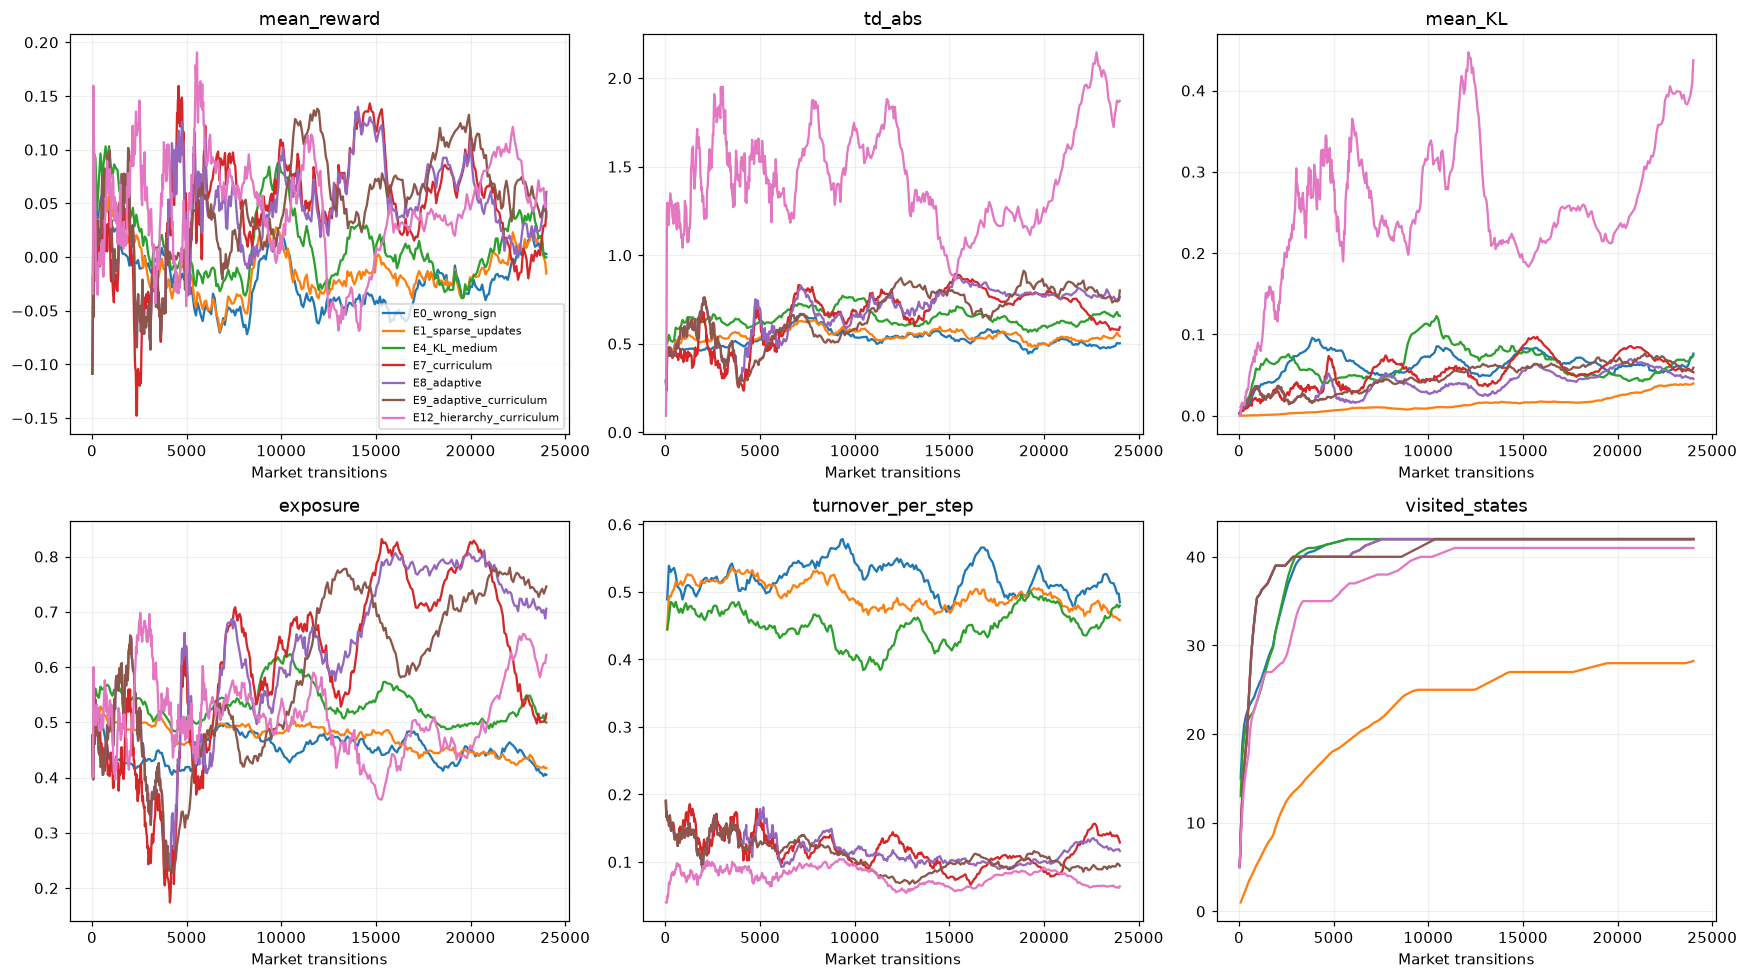

Adaptive curriculum promotions, seed 7 [{'steps': 4011, 'from_horizon': 21, 'reason': 'training threshold'}, {'steps': 8031, 'from_horizon': 60, 'reason': 'training threshold'}]
Adaptive curriculum promotions, seed 19 [{'steps': 4011, 'from_horizon': 21, 'reason': 'training threshold'}, {'steps': 8031, 'from_horizon': 60, 'reason': 'training threshold'}]
Adaptive curriculum promotions, seed 43 [{'steps': 4011, 'from_horizon': 21, 'reason': 'training threshold'}, {'steps': 8031, 'from_horizon': 60, 'reason': 'training threshold'}]


,experiment,unique_starts,unique_dates,updated_state_actions
0,E0_wrong_sign,240,1141,84
1,E1_sparse_updates,240,1141,53
2,E4_KL_medium,240,1141,84
3,E7_curriculum,424,1147,82
4,E8_adaptive,424,1147,84
5,E9_adaptive_curriculum,355,1147,83
6,E12_hierarchy_curriculum,391,1145,151


**Interpretation:** The logged promotion reason distinguishes training-threshold progress from forced budget progress. Exposure near zero can reduce both losses and growth; low turnover is not sufficient evidence of a good strategy. Broad date coverage is a necessary correction to the original fixed-start setup, but repeated overlapping windows remain dependent samples.

In [13]:
focus=['E0_wrong_sign','E1_sparse_updates','E4_KL_medium','E7_curriculum','E8_adaptive','E9_adaptive_curriculum','E12_hierarchy_curriculum']
fig,axes=plt.subplots(2,3,figsize=(16,9))
for name in focus:
 z=models[(name,SEEDS[0])]['logs']
 for ax,col in zip(axes.flat,['mean_reward','td_abs','mean_KL','exposure','turnover_per_step','visited_states']):
  ax.plot(z.steps,z[col].rolling(20,min_periods=1).mean(),label=name); ax.set(title=col,xlabel='Market transitions')
axes[0,0].legend(fontsize=7); show()
for seed in SEEDS:
 print('Adaptive curriculum promotions, seed',seed,models[('E9_adaptive_curriculum',seed)]['promotions'])
coverage=pd.DataFrame([{'experiment':name,'unique_starts':models[(name,SEEDS[0])]['logs'].unique_starts.iloc[-1],'unique_dates':models[(name,SEEDS[0])]['logs'].unique_market_dates.iloc[-1],'updated_state_actions':int((models[(name,SEEDS[0])]['visits']>0).sum())} for name in focus])
display(coverage)
explain('The logged promotion reason distinguishes training-threshold progress from forced budget progress. Exposure near zero can reduce both losses and growth; low turnover is not sufficient evidence of a good strategy. Broad date coverage is a necessary correction to the original fixed-start setup, but repeated overlapping windows remain dependent samples.')

## 15. Validation baselines and freeze the selected model

In [14]:
base_records=[]
for name in ['cash','buy_hold','trend','random']:
 base_records.append({'baseline':name,**metrics(evaluate(None,SPLITS['validation'],baseline=name))})
baselines_val=pd.DataFrame(base_records).set_index('baseline'); display(baselines_val)
eligible=summary.drop(index=['E0_wrong_sign','E1_sparse_updates'])
selected_name=eligible.median_score.idxmax()
candidates=validation[validation.experiment==selected_name].copy()
candidates['distance']=(candidates.score-candidates.score.median()).abs()
selected_seed=int(candidates.sort_values(['distance','seed']).iloc[0].seed)
selected=models[(selected_name,selected_seed)]
manifest={'dataset_sha256':DATA_HASH,'versions':versions,'seeds':SEEDS,'transition_budget':BUDGET,'fee_per_side':FEE,'gamma':GAMMA,'calibration_rows':CAL,'splits':SPLITS,'selection_rule':'max median validation(log_growth - 0.5*abs(max_drawdown)); representative median-score seed','selected_name':selected_name,'selected_seed':selected_seed,'config':asdict(selected['config']),'test_used_for_selection':False,'historical_test_previously_explored_in_EDA':True}
(OUT/'frozen_selection.json').write_text(json.dumps(manifest,indent=2))
np.savez_compressed(OUT/'selected_model.npz',G=selected['G'],visits=selected['visits'],vol_edges=vol_edges)
explain(f'Frozen selection: **{selected_name}, seed {selected_seed}**, median validation score **{eligible.loc[selected_name,"median_score"]:.4f}**. Buy-and-hold validation score is **{baselines_val.loc["buy_hold","score"]:.4f}**, cash score is zero. Selection among learned candidates does not imply the selected model beats those baselines.')

,net_return,log_growth,max_drawdown,annualized_vol,sharpe_0rf,exposure,turnover,unseen_decisions,score
baseline,,,,,,,,,
cash,0.00000,0.00000,0.00000,0.00000,NaN,0.00000,0,0,0.00000
buy_hold,0.57688,0.45545,-0.14742,0.27317,1.03610,1.00000,2,0,0.38174
trend,0.25010,0.22322,-0.15814,0.22564,0.64490,0.56652,12,0,0.14415
random,0.01755,0.01739,-0.17172,0.21779,0.14905,0.48069,220,0,-0.06847


**Interpretation:** Frozen selection: **E9_adaptive_curriculum, seed 7**, median validation score **0.2267**. Buy-and-hold validation score is **0.3817**, cash score is zero. Selection among learned candidates does not imply the selected model beats those baselines.

## 16. Final historical test: one frozen model and common baselines

,net_return,log_growth,max_drawdown,annualized_vol,sharpe_0rf,exposure,turnover,unseen_decisions,score
selected,0.59638,0.46774,-0.12694,0.16303,1.63357,0.64378,52.00000,4.00000,0.40427
cash,0.00000,0.00000,0.00000,0.00000,NaN,0.00000,0.00000,0.00000,0.00000
buy_hold,0.52743,0.42359,-0.15974,0.21203,1.18687,1.00000,2.00000,0.00000,0.34372
trend,0.35015,0.30022,-0.13646,0.17154,1.03234,0.67597,12.00000,0.00000,0.23198
random,0.09037,0.08652,-0.09998,0.13915,0.40589,0.48069,220.00000,0.00000,0.03653


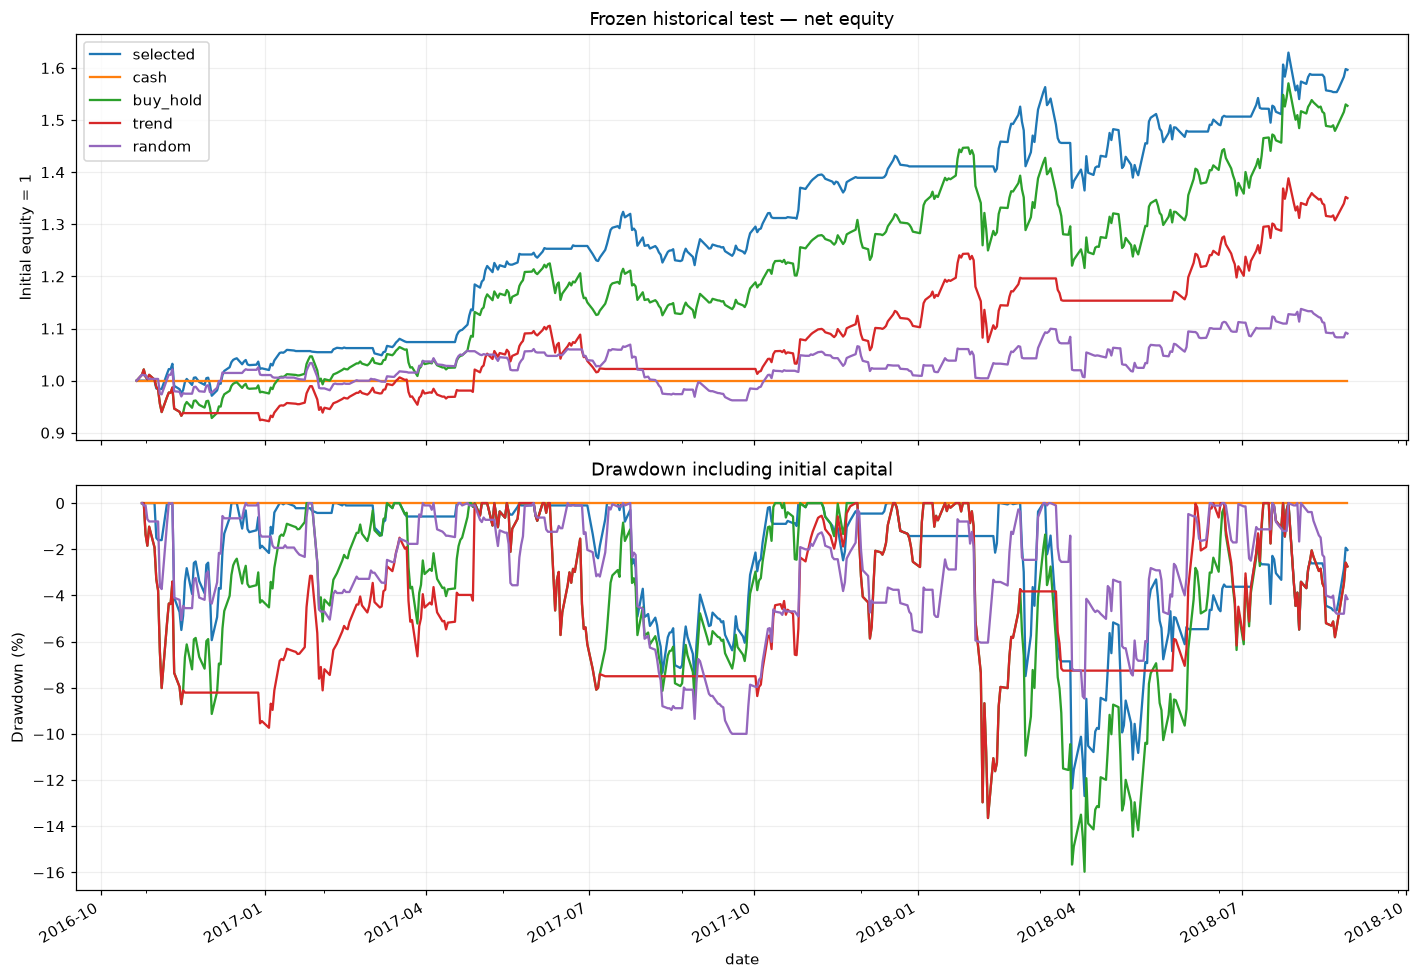

**Interpretation:** The frozen model returned **59.64%**, versus **52.74%** for buy-and-hold, with maximum drawdowns **-12.69%** and **-15.97%** respectively. Its exposure was **64.4%** with **52** one-way trades. It exceeded buy-and-hold net return on this path. This result is not used to retune the model.

In [15]:
test_paths={'selected':evaluate(selected,SPLITS['test'])}
for name in ['cash','buy_hold','trend','random']: test_paths[name]=evaluate(None,SPLITS['test'],baseline=name)
test_metrics=pd.DataFrame({name:metrics(path) for name,path in test_paths.items()}).T
display(test_metrics); test_metrics.to_csv(OUT/'final_test_metrics.csv')
fig,ax=plt.subplots(2,1,figsize=(13,9),sharex=True)
for name,path in test_paths.items():
 initial=pd.Series([1.],index=[df.index[SPLITS['test'][0]]])
 pd.concat([initial,path.equity]).plot(ax=ax[0],label=name)
 (path.drawdown*100).plot(ax=ax[1],label=name)
 path.to_csv(OUT/f'test_path_{name}.csv')
ax[0].set(title='Frozen historical test — net equity',ylabel='Initial equity = 1'); ax[0].legend()
ax[1].set(title='Drawdown including initial capital',ylabel='Drawdown (%)'); show()
s=test_metrics.loc['selected']; b=test_metrics.loc['buy_hold']
explain(f'The frozen model returned **{s.net_return:.2%}**, versus **{b.net_return:.2%}** for buy-and-hold, with maximum drawdowns **{s.max_drawdown:.2%}** and **{b.max_drawdown:.2%}** respectively. Its exposure was **{s.exposure:.1%}** with **{s.turnover:.0f}** one-way trades. {"It exceeded buy-and-hold net return on this path." if s.net_return>b.net_return else "It did not beat buy-and-hold net return on this path."} This result is not used to retune the model.')

## 17. Execution randomness and greedy-policy sensitivity

In [16]:
execution=pd.DataFrame([{'execution_seed':seed,**metrics(evaluate(selected,SPLITS['test'],execution_seed=seed))} for seed in range(100,120)])
display(execution[['net_return','max_drawdown','score','turnover']].describe(percentiles=[.1,.5,.9]))
greedy_metrics=metrics(evaluate(selected,SPLITS['test'],greedy=True)); display(pd.Series(greedy_metrics,name='greedy projection').to_frame())
execution.to_csv(OUT/'execution_seed_sensitivity.csv',index=False)
explain(f'Across 20 execution seeds the frozen stochastic policy’s return ranges **{execution.net_return.min():.2%}–{execution.net_return.max():.2%}**, median **{execution.net_return.median():.2%}**. This range is policy-sampling variability on the same market history, not 20 independent market tests. The primary reported path remains execution seed 2026.')

,net_return,max_drawdown,score,turnover
count,20.00000,20.00000,20.00000,20.00000
mean,0.28556,-0.14997,0.17399,45.10000
std,0.08736,0.01817,0.07160,7.03300
min,0.11527,-0.20505,0.02775,30.00000
10%,0.17954,-0.16429,0.08878,34.00000
50%,0.28752,-0.14814,0.17935,45.00000
90%,0.41617,-0.13608,0.27360,52.00000
max,0.42805,-0.11653,0.28224,56.00000


,greedy projection
net_return,0.21090
log_growth,0.19136
max_drawdown,-0.14814
annualized_vol,0.17355
sharpe_0rf,0.68313
exposure,0.57082
turnover,22.00000
unseen_decisions,4.00000
score,0.11729


**Interpretation:** Across 20 execution seeds the frozen stochastic policy’s return ranges **11.53%–42.81%**, median **28.75%**. This range is policy-sampling variability on the same market history, not 20 independent market tests. The primary reported path remains execution seed 2026.

## 18. Transaction-cost stress test without retraining

strategy,buy_hold,selected,trend
fee_bps_per_side,,,
0,0.53049,0.68163,0.36646
5,0.52896,0.63846,0.35828
10,0.52743,0.59638,0.35015
25,0.52284,0.47639,0.32602
50,0.51522,0.29578,0.28669
100,0.50003,-0.00285,0.21121
150,0.48492,-0.23367,0.13981


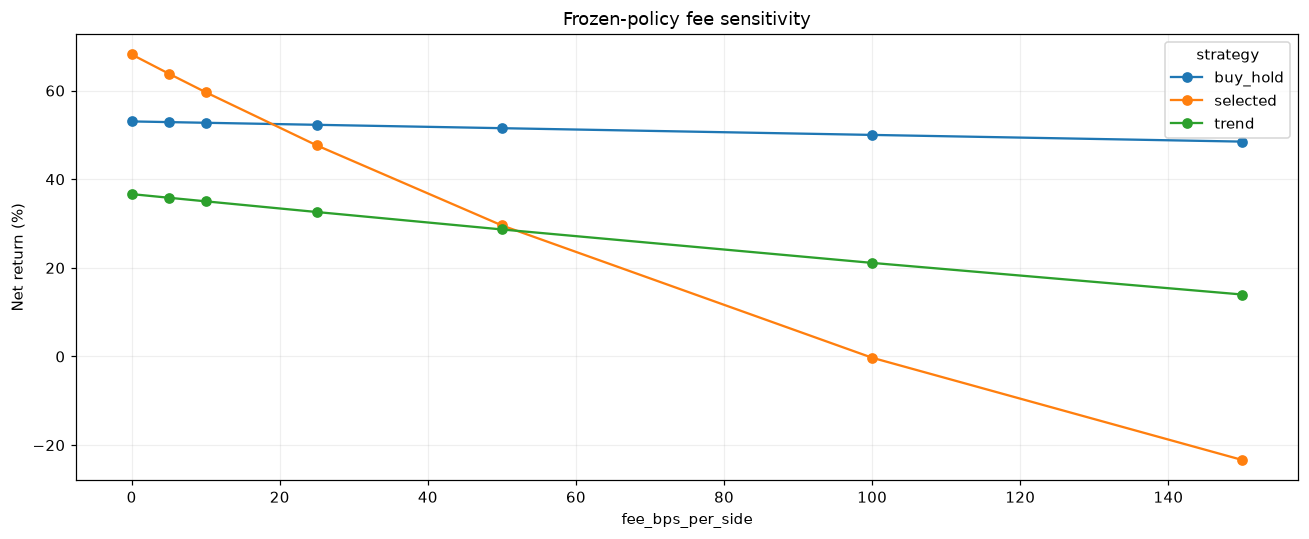

**Interpretation:** Compare the slopes: a strategy with frequent switches typically loses more as per-side fees rise. The zero-fee point measures how much of a failure is already present before fees. Terminal exit fees are included at every fee level. This simulator still omits spread variability and market impact.

In [17]:
stress=[]
for bps in [0,5,10,25,50,100,150]:
 for name in ['selected','buy_hold','trend']:
  path=evaluate(selected if name=='selected' else None,SPLITS['test'],fee=bps/10000,baseline=None if name=='selected' else name)
  stress.append({'fee_bps_per_side':bps,'strategy':name,**metrics(path)})
stress=pd.DataFrame(stress); display(stress.pivot(index='fee_bps_per_side',columns='strategy',values='net_return'))
(stress.pivot(index='fee_bps_per_side',columns='strategy',values='net_return')*100).plot(marker='o',ylabel='Net return (%)',title='Frozen-policy fee sensitivity'); show()
stress.to_csv(OUT/'cost_sensitivity.csv',index=False)
explain('Compare the slopes: a strategy with frequent switches typically loses more as per-side fees rise. The zero-fee point measures how much of a failure is already present before fees. Terminal exit fees are included at every fee level. This simulator still omits spread variability and market impact.')

## 19. Error attribution by calendar block, exposure and state support

In [18]:
path=test_paths['selected']; bench=test_paths['buy_hold']
by_year=pd.DataFrame({'selected_log':path.log_return,'buy_hold_log':bench.log_return,'position':path.position,'turnover':path.turnover}).groupby(path.index.year).agg(selected_log=('selected_log','sum'),buy_hold_log=('buy_hold_log','sum'),exposure=('position','mean'),turnover=('turnover','sum'))
by_year['selected_return']=np.expm1(by_year.selected_log); by_year['buy_hold_return']=np.expm1(by_year.buy_hold_log)
display(by_year)
zero=evaluate(selected,SPLITS['test'],fee=0)
assert np.array_equal(zero.position,path.position)
fee_drag=zero.log_return.sum()-path.log_return.sum()
print('Total log-growth fee drag:',fee_drag,'| Expected:',-path.turnover.sum()*np.log(1-FEE))
assert np.isclose(fee_drag,-path.turnover.sum()*np.log(1-FEE))
display(path.nsmallest(10,'log_return'))
display(pd.crosstab(path.position.shift(1),path.position,rownames=['previous exposure'],colnames=['new exposure']))
display(pd.Series(selected['visits'].sum(axis=1)).describe().to_frame('training visits by state'))
explain(f'Total log-growth lost to modeled fees is **{fee_drag:.4f}**. The primary test path encountered **{int(path.unseen_decision.sum())} unseen-state decisions**. Missing upside while in cash, trading costs, downside while long, and unsupported states are different failure modes; the tables separate them without assigning unsupported event narratives.')

,selected_log,buy_hold_log,exposure,turnover,selected_return,buy_hold_return
date,,,,,,
2016,0.02338,-0.02169,0.81250,3,0.02366,-0.02146
2017,0.32099,0.27314,0.62550,33,0.37849,0.31409
2018,0.12337,0.17213,0.62275,16,0.13130,0.18783


Total log-growth fee drag: 0.05202601734634377 | Expected: 0.05202601734634379


,log_return,position,turnover,unseen_decision,option,return,equity,drawdown
date,,,,,,,,
2018-03-28,-0.06103,1,1,False,1,-0.05921,1.36991,-0.12372
2018-03-02,-0.04758,1,0,False,1,-0.04647,1.41144,-0.07495
2016-11-11,-0.04184,1,0,False,1,-0.04098,0.99001,-0.04098
2018-07-30,-0.03478,1,0,False,1,-0.03419,1.57378,-0.03419
2018-03-19,-0.03308,1,0,False,1,-0.03254,1.49119,-0.04614
2018-04-25,-0.02820,1,0,False,1,-0.02780,1.40798,-0.09937
2017-07-25,-0.02382,1,0,False,1,-0.02354,1.28902,-0.02638
2018-04-06,-0.02251,1,0,False,1,-0.02226,1.39889,-0.10519
2018-03-14,-0.02246,1,0,False,1,-0.02221,1.52860,-0.02221


new exposure,0,1
previous exposure,,
0.00000,139,26
1.00000,26,274


,training visits by state
count,54.00000
mean,444.44444
std,738.54246
min,0.00000
25%,11.50000
50%,68.50000
75%,603.50000
max,"2,885.00000"


**Interpretation:** Total log-growth lost to modeled fees is **0.0520**. The primary test path encountered **4 unseen-state decisions**. Missing upside while in cash, trading costs, downside while long, and unsupported states are different failure modes; the tables separate them without assigning unsupported event narratives.

## 20. Paired block-bootstrap uncertainty versus buy-and-hold

In [19]:
difference=(path.log_return-bench.log_return).to_numpy(); rng=np.random.default_rng(987)
uncertainty=[]
for block in [5,10,21]:
 means=[]
 for _ in range(2000):
  starts=rng.integers(0,len(difference),size=int(np.ceil(len(difference)/block)))
  idx=((starts[:,None]+np.arange(block))%len(difference)).ravel()[:len(difference)]
  means.append(difference[idx].mean())
 low,high=np.quantile(means,[.025,.975])
 uncertainty.append({'block_sessions':block,'mean_daily_log_difference':difference.mean(),'CI_low':low,'CI_high':high})
uncertainty=pd.DataFrame(uncertainty); display(uncertainty)
uncertainty.to_csv(OUT/'paired_bootstrap.csv',index=False)
explain(f'Mean daily log-return difference is **{difference.mean():+.5f}**. Zero lies inside **{((uncertainty.CI_low<=0)&(uncertainty.CI_high>=0)).sum()}/3** intervals. These conditional intervals should not be reported as proof that the selected algorithm generalizes.')

,block_sessions,mean_daily_log_difference,CI_low,CI_high
0,5,0.00009,-0.00071,0.00096
1,10,0.00009,-0.00064,0.00089
2,21,0.00009,-0.00058,0.00075


**Interpretation:** Mean daily log-return difference is **+0.00009**. Zero lies inside **3/3** intervals. These conditional intervals should not be reported as proof that the selected algorithm generalizes.

## 21. Expanding-window robustness inside the training period

In [20]:
folds=[(CAL,800,1050),(CAL,1050,TRAIN_END)]; walk=[]
for number,(lo,train_stop,eval_stop) in enumerate(folds,1):
 for seed in SEEDS:
  m=train(selected['config'],seed,budget=12000,bounds=(lo,train_stop))
  met=metrics(evaluate(m,(train_stop,eval_stop)))
  baseline=metrics(evaluate(None,(train_stop,eval_stop),baseline='buy_hold'))
  walk.append({'fold':number,'seed':seed,'train_last':str(df.index[train_stop-1].date()),'evaluation_first':str(df.index[train_stop].date()),'evaluation_last':str(df.index[eval_stop-1].date()),**met,'buy_hold_return':baseline['net_return']})
walk=pd.DataFrame(walk); display(walk); walk.to_csv(OUT/'retrospective_expanding_folds.csv',index=False)
explain('Differences across folds indicate sensitivity to the historical period and amount of training support. The configuration is not changed in response to these results. A future stronger study would perform configuration selection independently within every outer fold and preserve a genuinely unseen final period.')

,fold,seed,train_last,evaluation_first,evaluation_last,net_return,log_growth,max_drawdown,annualized_vol,sharpe_0rf,exposure,turnover,unseen_decisions,score,buy_hold_return
0,1,7,2012-07-24,2012-07-25,2013-07-24,0.17916,0.16480,-0.07501,0.12531,1.39358,0.41365,24,0,0.12729,0.48844
1,1,19,2012-07-24,2012-07-25,2013-07-24,0.14721,0.13733,-0.08818,0.11538,1.26215,0.35341,16,0,0.09324,0.48844
2,1,43,2012-07-24,2012-07-25,2013-07-24,0.12783,0.12029,-0.08874,0.12261,1.05401,0.40964,22,0,0.07593,0.48844
3,2,7,2013-07-24,2013-07-25,2014-12-12,-0.06508,-0.06729,-0.15190,0.15096,-0.24520,0.62571,36,1,-0.14324,0.17659
4,2,19,2013-07-24,2013-07-25,2014-12-12,-0.01893,-0.01912,-0.09204,0.13767,-0.03116,0.60571,32,1,-0.06514,0.17659
5,2,43,2013-07-24,2013-07-25,2014-12-12,0.11952,0.11290,-0.11505,0.16955,0.56338,0.63714,26,1,0.05538,0.17659


**Interpretation:** Differences across folds indicate sensitivity to the historical period and amount of training support. The configuration is not changed in response to these results. A future stronger study would perform configuration selection independently within every outer fold and preserve a genuinely unseen final period.

## 22. Hierarchy-specific inspection

,fraction_of_sessions
option,
long,0.48283
RSI reversion,0.21674
cash,0.17167
trend,0.12876


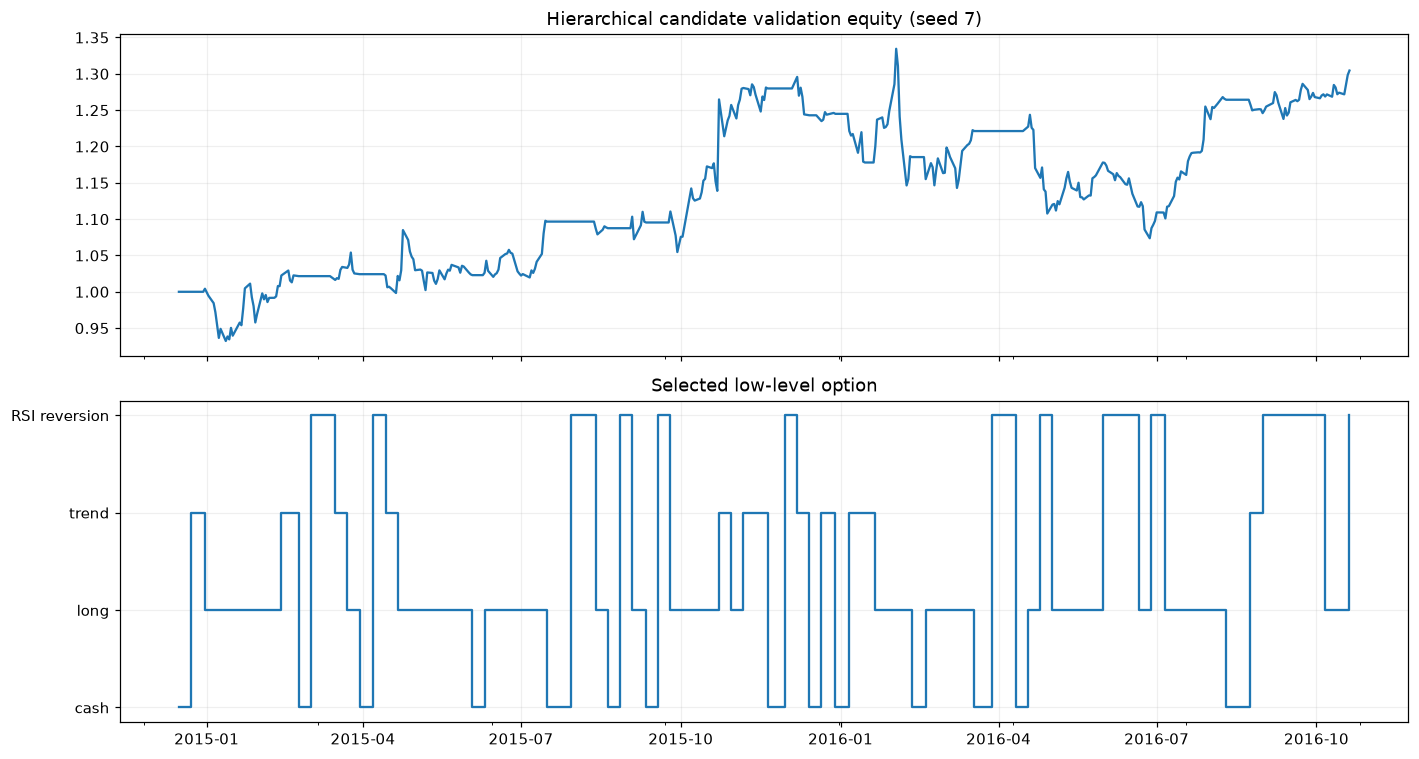

**Interpretation:** This is a learned options manager with rule-based execution policies, not a claim that both hierarchy levels were trained. The SMDP target discounts by the actual option length. Five-session commitment reduces decision frequency but may delay useful exposure changes; the paired E11/E12 results determine whether curriculum helped that architecture here.

In [21]:
hmodel=models[('E12_hierarchy_curriculum',7)]
hpath=evaluate(hmodel,SPLITS['validation'])
option_names={0:'cash',1:'long',2:'trend',3:'RSI reversion'}
use=hpath.option.map(option_names).value_counts(normalize=True).rename('fraction_of_sessions')
display(use.to_frame())
fig,ax=plt.subplots(2,1,figsize=(13,7),sharex=True)
hpath.equity.plot(ax=ax[0],title='Hierarchical candidate validation equity (seed 7)')
ax[1].step(hpath.index,hpath.option,where='post'); ax[1].set(yticks=list(option_names),yticklabels=list(option_names.values()),title='Selected low-level option'); show()
explain('This is a learned options manager with rule-based execution policies, not a claim that both hierarchy levels were trained. The SMDP target discounts by the actual option length. Five-session commitment reduces decision frequency but may delay useful exposure changes; the paired E11/E12 results determine whether curriculum helped that architecture here.')

## 23. Evidence-based conclusion and next experiments

In [22]:
best=summary.loc[selected_name]
explain(f'**Correctness:** dataset/date anchors, causal features, cost/reward sign, terminal accounting, soft Bellman identity, frozen evaluation and fee reconciliation passed their assertions. The selected candidate is **{selected_name}**, seed **{selected_seed}**.')
explain(f'**Validation:** selected configuration median score **{best.median_score:.4f}**, median net return **{best.median_return:.2%}**. Baseline buy-and-hold score **{baselines_val.loc["buy_hold","score"]:.4f}**. A selected learned policy can still be inferior to doing nothing or holding the asset.')
explain(f'**Final historical test:** selected return **{test_metrics.loc["selected","net_return"]:.2%}**, buy-and-hold **{test_metrics.loc["buy_hold","net_return"]:.2%}**. Selected max drawdown **{test_metrics.loc["selected","max_drawdown"]:.2%}**. {"There is a positive relative return on this path, requiring new-data confirmation." if test_metrics.loc["selected","net_return"]>test_metrics.loc["buy_hold","net_return"] else "The corrected experiment does not establish a profitable advantage over buy-and-hold; retain the baseline and investigate the documented failure modes."}')
explain('**Next bounded experiments:** independently nested chronological selection; additional assets chosen without outcome filtering; broader training-seed replication; richer but regularized states; learned option workers after the fixed-option manager is justified; realistic spread/slippage data. These are follow-up hypotheses, not changes fitted to this final segment.')
# Save the full protocol and every tested configuration for reproducibility.
(OUT/'experiment_configs.json').write_text(json.dumps([asdict(c) for c in CONFIGS],indent=2))
(OUT/'requirements_versions.txt').write_text('\n'.join(f'{p}=={v}' for p,v in versions.items())+'\n')
print('Artifacts saved in:',OUT.resolve())

**Interpretation:** **Correctness:** dataset/date anchors, causal features, cost/reward sign, terminal accounting, soft Bellman identity, frozen evaluation and fee reconciliation passed their assertions. The selected candidate is **E9_adaptive_curriculum**, seed **7**.

**Interpretation:** **Validation:** selected configuration median score **0.2267**, median net return **37.71%**. Baseline buy-and-hold score **0.3817**. A selected learned policy can still be inferior to doing nothing or holding the asset.

**Interpretation:** **Final historical test:** selected return **59.64%**, buy-and-hold **52.74%**. Selected max drawdown **-12.69%**. There is a positive relative return on this path, requiring new-data confirmation.

**Interpretation:** **Next bounded experiments:** independently nested chronological selection; additional assets chosen without outcome filtering; broader training-seed replication; richer but regularized states; learned option workers after the fixed-option manager is justified; realistic spread/slippage data. These are follow-up hypotheses, not changes fitted to this final segment.

Artifacts saved in: /Users/rashiojha/Downloads/untitled folder 8/experiment_outputs


## 24. How to read and reproduce this study

Run all notebook cells in order, or run `python Corrected_G_Learning_Experiments.py` in an environment containing the listed packages. The program writes tables, the selection manifest, a compressed G/visit table and daily evaluation paths under `experiment_outputs/`. The saved notebook is the convenient version for reading outputs alongside comments.

**Limits:** one historical asset, dependent windows, 3 training seeds, a small prespecified configuration search, a simplified cash/long simulator, fixed calibration bins and fixed option workers. Uniform KL can encourage costly random switching; a holding prior can reduce turnover but can also preserve an unhelpful exposure. Curriculum and adaptive updates are hypotheses to test, not guaranteed improvements. Cost changes, execution policy changes and hierarchy changes must be reported explicitly.

**What “correctly” means here:** the equations match the implemented objective; the portfolio accounting reconciles; decisions use available information; boundaries and costs are explicit; comparisons are controlled; and saved conclusions reflect actual outcomes. It does not mean historical market prediction becomes easy or that the selected strategy should be deployed.

**Primary theoretical sources:** [G-learning, Fox et al.](https://arxiv.org/abs/1512.08562); [temporal abstraction/options, Sutton et al.](https://www.sciencedirect.com/science/article/pii/S0004370299000521). Package behavior is audited directly from the installed source in Section 3.

## 25. Final artifact checks and robustness verdict

This final cell reloads exported results rather than relying on hidden training state. It verifies the experiment matrix and transition budgets and computes the execution-seed win rate. The primary seed was fixed in advance, but reporting it alone would conceal material variability.

In [23]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
out = Path('experiment_outputs')
runs = pd.read_csv(out / 'validation_runs.csv')
trace = pd.read_csv(out / 'training_diagnostics.csv')
execution = pd.read_csv(out / 'execution_seed_sensitivity.csv')
final = pd.read_csv(out / 'final_test_metrics.csv', index_col=0)
assert len(runs) == 39 and runs.groupby('experiment').size().eq(3).all()
assert trace.groupby(['experiment', 'seed']).steps.max().eq(24000).all()
assert np.isfinite(runs[['net_return', 'log_growth', 'max_drawdown', 'score']]).all().all()
assert runs[runs.experiment == 'E4_KL_medium'].training_updates.eq(24000).all()
assert runs[runs.experiment == 'E11_hierarchy'].training_updates.eq(4800).all()
beat = int((execution.net_return > final.loc['buy_hold', 'net_return']).sum())
verdict = pd.Series({
    'primary_path_return': final.loc['selected', 'net_return'],
    'additional_execution_median_return': execution.net_return.median(),
    'buy_hold_return': final.loc['buy_hold', 'net_return'],
    'additional_execution_paths_beating_buy_hold': beat,
    'additional_execution_paths': len(execution)
})
display(verdict.to_frame('Observed result'))
display(Markdown(f'**Final interpretation:** only **{beat}/{len(execution)}** additional execution paths beat buy-and-hold. The corrected code and validation winner do **not** establish a reliable performance improvement. Keep the baseline, the failed ablations, and the randomness results visible.'))
print('PASS: 39 runs, three seeds per configuration, equal transition budgets, finite metrics, and primitive/option update counts.')

,Observed result
primary_path_return,0.596382
additional_execution_median_return,0.287525
buy_hold_return,0.527428
additional_execution_paths_beating_buy_hold,0.000000
additional_execution_paths,20.000000


**Final interpretation:** only **0/20** additional execution paths beat buy-and-hold. The corrected code and validation winner do **not** establish a reliable performance improvement. Keep the baseline, the failed ablations, and the randomness results visible.

PASS: 39 runs, three seeds per configuration, equal transition budgets, finite metrics, and primitive/option update counts.
